<a href="https://colab.research.google.com/github/dthompson2003/Digital-Imaging-Final/blob/main/Data/data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instructions On Running The Trained Model



*   **Run the first cell** (*clones repo and installs dependencies*)
*   **Run the second cell** (*creates directory and copies the trained model over to the created directory. Also make  sure you have the trained model inside of your google drive with the same file path*)
*   **Run the testing cell** (*Should be second to last cell. Labeled with '# Testing Run Cell'* )
*   **Run the cell after that** (*has canvas to draw the input*)


In [1]:
# @title Default title text
import os

# Define the absolute path where the repository should be
absolute_repo_path = '/content/pix2pixHD'
repo_name = 'pix2pixHD' # Name of the directory git clone will create

# Change to /content to ensure cloning happens at the top level
current_dir = os.getcwd()
if current_dir != '/content':
    os.chdir('/content')
    print(f"Changed current working directory to: {os.getcwd()}")


# Clone the pix2pixHD repository if it doesn't already exist at the absolute_repo_path
if not os.path.exists(absolute_repo_path):
    !git clone https://github.com/NVIDIA/pix2pixHD.git
    print(f"Repository '{repo_name}' cloned successfully to {absolute_repo_path}.")
else:
    print(f"Repository '{absolute_repo_path}' already exists. Skipping clone.")

# Always navigate into the repository directory using its absolute path
os.chdir(absolute_repo_path)
print(f"Current working directory changed to: {os.getcwd()}")


# Installing the dependencies
!pip install dominate

Cloning into 'pix2pixHD'...
remote: Enumerating objects: 343, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 343 (delta 0), reused 0 (delta 0), pack-reused 340 (from 1)
Receiving objects: 100% (343/343), 55.68 MiB | 15.27 MiB/s, done.
Resolving deltas: 100% (156/156), done.
Repository 'pix2pixHD' cloned successfully to /content/pix2pixHD.
Current working directory changed to: /content/pix2pixHD


In [2]:
# RUN THIS CELL IF YOU ARE TESTING, NOT TRAINING
# THIS CODE IS USED TO ACCESS THE ALREADY TRAINED MODELS
from google.colab import drive
drive.mount('/content/drive')

# CREATES FOLDER IN YOUR CURRENT DIRECTORY
!mkdir -p checkpoints/terrain_pix2pixHD_rgb
# COPIES ALREADY TRAINED MODEL INTO CREATED DIRECTORY
!cp /content/drive/MyDrive/CGAN\ Files/200_net_G.pth \
    checkpoints/terrain_pix2pixHD_rgb/

Mounted at /content/drive


In [4]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("tpapp157/earth-terrain-height-and-segmentation-map-images")


Using Colab cache for faster access to the 'earth-terrain-height-and-segmentation-map-images' dataset.


In [5]:
print("Path to dataset files:", path)

heightMapData = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith("h.png"):
            full_path = os.path.join(root, file)
            heightMapData.append(full_path)

# Sort heightMapData based on the numerical part of the filename
heightMapData.sort(key=lambda x: int(os.path.basename(x).split('_')[0]))

print("Number of height map files:", len(heightMapData))


for file in heightMapData[:10]:   # show first 10
    print(file)

heightMapData = heightMapData[:100]

print("Number of height map files:", len(heightMapData))


for file in heightMapData[:10]:   # show first 10
    print(file)

Path to dataset files: /kaggle/input/earth-terrain-height-and-segmentation-map-images
Number of height map files: 5000
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0001_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0002_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0003_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0004_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0005_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0006_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0007_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0008_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0009_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0010_h.png
Number of height map files: 100
/kaggle/input/earth

In [6]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

processed_height_maps = []

for i, file_path in enumerate(heightMapData):
    # Open the image
    img = Image.open(file_path)

    # Convert image to a NumPy array (float type for division)
    img_array = np.array(img, dtype=np.float32)

    # Find the maximum pixel value in the current image
    max_val = np.max(img_array)

    # Normalize the image array if max_val is not zero
    if max_val > 0:
        normalized_img_array = img_array / max_val
    else:
        normalized_img_array = img_array # Image is all black, no normalization needed

    processed_height_maps.append(normalized_img_array)

print(f"Processed {len(processed_height_maps)} height map images.")
print(f"Example: The maximum pixel value in the first processed image is: {np.max(processed_height_maps[0])}")

Processed 100 height map images.
Example: The maximum pixel value in the first processed image is: 1.0


Let's visualize the first original and processed height map to see the effect of normalization.

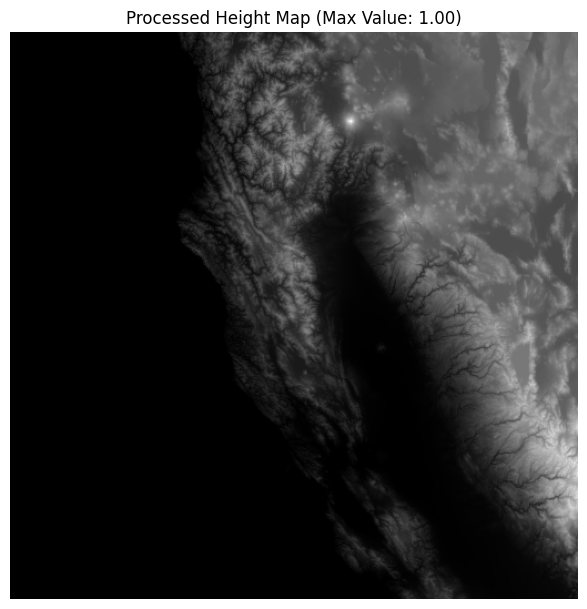

In [20]:
# Load the first original image for comparison
original_img_path = heightMapData[0]
original_img = Image.open(original_img_path)

# Get the first processed image array
first_processed_img_array = processed_height_maps[0]

plt.figure(figsize=(12, 6))



plt.subplot(1, 2, 2)
plt.imshow(first_processed_img_array, cmap='gray')
plt.title(f'Processed Height Map (Max Value: {np.max(first_processed_img_array):.2f})')
plt.axis('off')

plt.tight_layout()
plt.show()

Let's visualize the first 5 original and processed height maps.

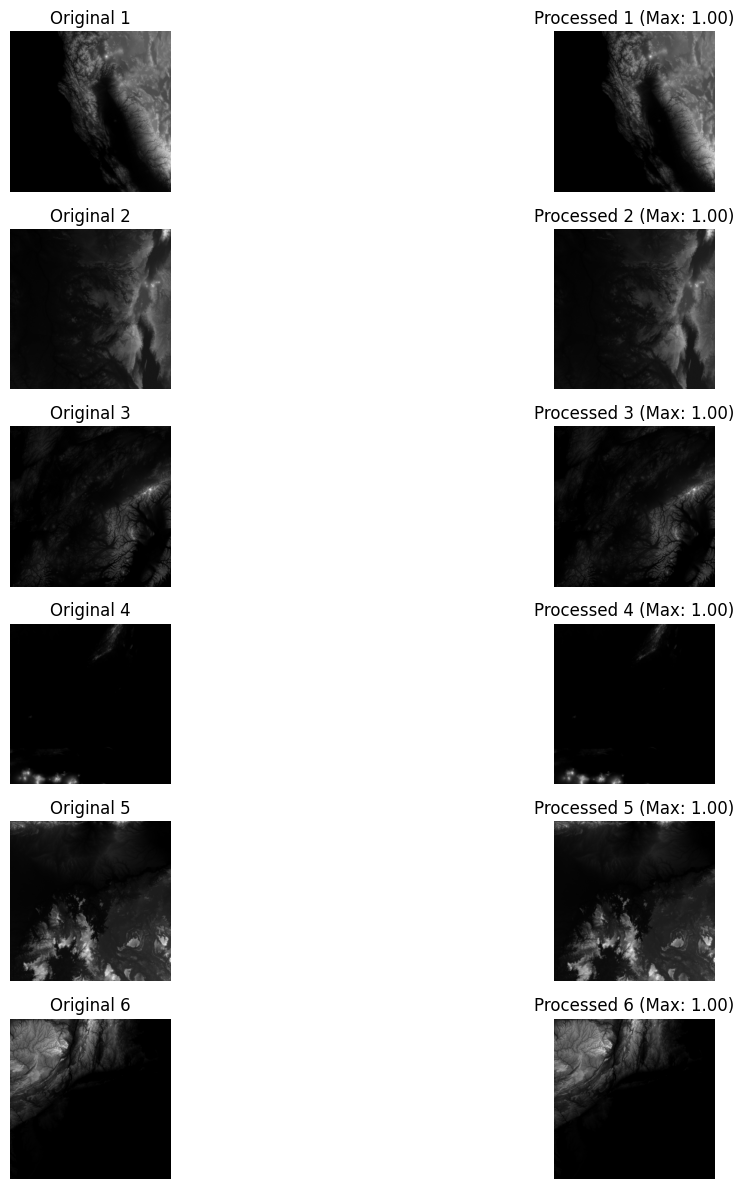

In [8]:
num_images_to_display = 6

plt.figure(figsize=(15, 2 * num_images_to_display))

for i in range(num_images_to_display):
    # Load the original image
    original_img_path = heightMapData[i]
    original_img = Image.open(original_img_path)

    # Get the processed image array
    processed_img_array = processed_height_maps[i]

    # Plot original image
    plt.subplot(num_images_to_display, 2, 2 * i + 1)
    plt.imshow(original_img, cmap='gray')
    plt.title(f'Original {i+1}')
    plt.axis('off')

    # Plot processed image
    plt.subplot(num_images_to_display, 2, 2 * i + 2)
    plt.imshow(processed_img_array, cmap='gray')
    plt.title(f'Processed {i+1} (Max: {np.max(processed_img_array):.2f})')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:

print("Path to dataset files:", path)
edgeMapData = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith("i2.png"):
            full_path = os.path.join(root, file)
            edgeMapData.append(full_path)

edgeMapData.sort(key=lambda x: int(os.path.basename(x).split('_')[0]))
print("Number of i2 map files:", len(edgeMapData))

for file in edgeMapData[:10]:   # show first 10
    print(file)

edgeMapData = edgeMapData[:100]

print("Number of i2 map files:", len(edgeMapData))

for file in edgeMapData[:10]:   # show first 10
    print(file)

Path to dataset files: /kaggle/input/earth-terrain-height-and-segmentation-map-images
Number of i2 map files: 5000
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0001_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0002_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0003_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0004_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0005_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0006_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0007_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0008_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0009_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0010_i2.png
Number of i2 map files: 100
/kaggle/input/ear

/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0001_i2.png


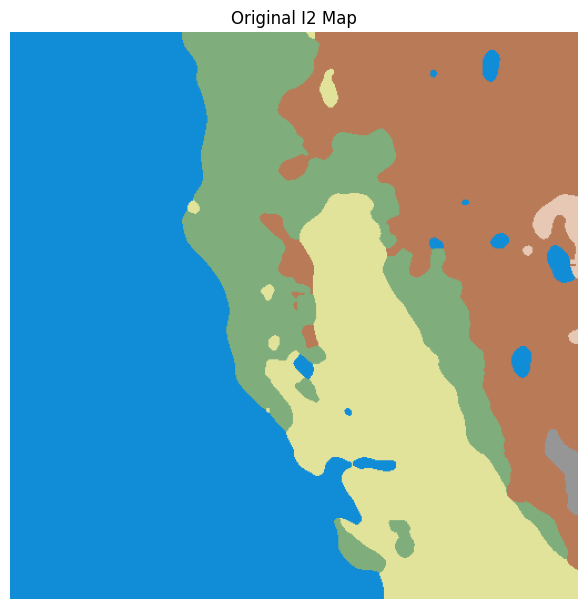

In [10]:
# Load the first original image for comparison
original_i2_path = edgeMapData[0]
original_i2 = Image.open(original_i2_path)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_i2)
plt.title('Original I2 Map', print(edgeMapData[0]))
plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
from skimage import feature

processed_edge_maps = []

for i, file_path in enumerate(edgeMapData):
    # Open the image in grayscale
    img = Image.open(file_path).convert('L')

    # Convert image to a NumPy array
    img_array = np.array(img)

    # Apply Canny edge detection
    # sigma is the standard deviation of the Gaussian filter
    # You might need to adjust sigma and other parameters for optimal results
    edges = feature.canny(img_array, sigma=1)

    processed_edge_maps.append(edges)

print(f"Processed {len(processed_edge_maps)} edge map images.")
print(f"Example: The shape of the first processed edge map is: {processed_edge_maps[0].shape}")

Processed 100 edge map images.
Example: The shape of the first processed edge map is: (512, 512)


Let's visualize the first original and processed edge map to see the effect of Canny edge detection.

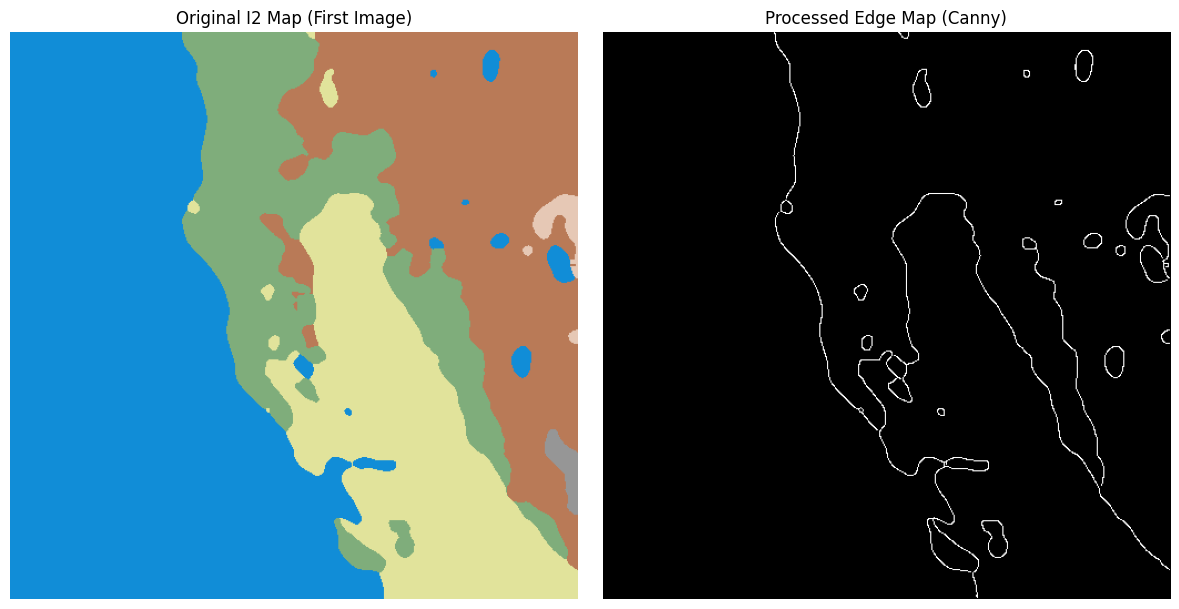

In [12]:
# Load the first original image for comparison
original_i2_path = edgeMapData[0]
original_i2_img = Image.open(original_i2_path)

# Get the first processed edge map array
first_processed_edge_map = processed_edge_maps[0]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_i2_img, cmap='gray')
plt.title('Original I2 Map (First Image)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(first_processed_edge_map, cmap='gray')
plt.title('Processed Edge Map (Canny)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
from PIL import Image
import os
import shutil # Import shutil for directory removal

# 1. Setup Directories
dataset_name = 'my_terrain_data_rgb'
base_path = f'/content/pix2pixHD/datasets/{dataset_name}'

# Define paths for train_A and train_B
train_A_path = os.path.join(base_path, 'train_A')
train_B_path = os.path.join(base_path, 'train_B')

# Ensure directories are clean before populating
if os.path.exists(train_A_path): shutil.rmtree(train_A_path)
if os.path.exists(train_B_path): shutil.rmtree(train_B_path)

os.makedirs(train_A_path, exist_ok=True)
os.makedirs(train_B_path, exist_ok=True)

print("Processing and resizing images to 512x512 RGB...")

# 2. Process and Save Images as RGB
for i in range(len(processed_height_maps)):
    # Get the processed edge map (input A)
    # Convert boolean array to uint8 (0 or 255) for image saving
    edge_array = (processed_edge_maps[i].astype(np.uint8) * 255)
    edge_img = Image.fromarray(edge_array, mode='L') # Create grayscale PIL Image

    # Get the processed height map (target B)
    # Denormalize float array (0-1) to uint8 (0-255) for image saving
    height_array = (processed_height_maps[i] * 255).astype(np.uint8)
    height_img = Image.fromarray(height_array, mode='L') # Create grayscale PIL Image

    # Resize both images and convert to RGB
    edge_img = edge_img.resize((512, 512), Image.BICUBIC).convert('RGB')
    height_img = height_img.resize((512, 512), Image.BICUBIC).convert('RGB')

    filename = f'img_{i:04d}.png'

    edge_img.save(os.path.join(train_A_path, filename))
    height_img.save(os.path.join(train_B_path, filename))

print(f"Successfully saved {len(processed_height_maps)} RGB image pairs to {base_path}")

Processing and resizing images to 512x512 RGB...


/tmp/ipykernel_2820/2115806776.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  edge_img = Image.fromarray(edge_array, mode='L') # Create grayscale PIL Image
/tmp/ipykernel_2820/2115806776.py:33: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  height_img = Image.fromarray(height_array, mode='L') # Create grayscale PIL Image


Successfully saved 100 RGB image pairs to /content/pix2pixHD/datasets/my_terrain_data_rgb


In [14]:
import os

dataset_path = '/content/pix2pixHD/datasets/my_terrain_data_rgb'

num_files_A = len(os.listdir(os.path.join(dataset_path, 'train_A')))
num_files_B = len(os.listdir(os.path.join(dataset_path, 'train_B')))

print(f"Number of images in train_A: {num_files_A}")
print(f"Number of images in train_B: {num_files_B}")

if num_files_A == 100 and num_files_B == 100:
    print("Confirmed: train_A and train_B contain 100 images each.")
else:
    print(f"Warning: Unexpected number of images found. train_A has {num_files_A} and train_B has {num_files_B}.")

Number of images in train_A: 100
Number of images in train_B: 100
Confirmed: train_A and train_B contain 100 images each.


In [ ]:
# 1. Reset all repository files to original state
!git checkout data/aligned_dataset.py data/base_dataset.py models/pix2pixHD_model.py

# Fix for fractions.gcd in train.py due to Python version changes
# It was moved to math.gcd in Python 3.5+
import re
import math

train_py_path = './train.py'
with open(train_py_path, 'r') as f:
    train_py_content = f.read()

# Replace fractions.gcd with math.gcd and ensure math is imported
if 'fractions.gcd' in train_py_content:
    # Add 'import math' if not already present
    if 'import math' not in train_py_content:
        train_py_content = re.sub(r'import \S+', 'import math\n\g<0>', train_py_content, 1) # Insert after first import
    train_py_content = train_py_content.replace('fractions.gcd', 'math.gcd')
    with open(train_py_path, 'w') as f:
        f.write(train_py_content)
    print(f"Fixed 'fractions.gcd' to 'math.gcd' in {train_py_path}")
else:
    print(f"'fractions.gcd' not found in {train_py_path}. Assuming it's already fixed or not an issue.")

# 2. Training run using the new RGB dataset
# Note: input_nc and output_nc now use the default 3
train_cmd = (
    "python train.py "
    "--dataroot ./datasets/my_terrain_data_rgb "
    "--name terrain_pix2pixHD_rgb "
    "--label_nc 0 "
    "--no_instance "
    "--resize_or_crop none "
    "--save_epoch_freq 5 "
    "--gpu_ids 0 "
    "--batchSize 1"
)

print(f"Starting training with RGB dataset...\n{train_cmd}")
!{train_cmd}

Updated 0 paths from the index


<>:17: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_1025/1674182621.py:17: SyntaxWarning: invalid escape sequence '\g'
  train_py_content = re.sub(r'import \S+', 'import math\n\g<0>', train_py_content, 1) # Insert after first import


Fixed 'fractions.gcd' to 'math.gcd' in ./train.py
Starting training with RGB dataset...
python train.py --dataroot ./datasets/my_terrain_data_rgb --name terrain_pix2pixHD_rgb --label_nc 0 --no_instance --resize_or_crop none --save_epoch_freq 5 --gpu_ids 0 --batchSize 1
------------ Options -------------
batchSize: 1
beta1: 0.5
checkpoints_dir: ./checkpoints
continue_train: False
data_type: 32
dataroot: ./datasets/my_terrain_data_rgb
debug: False
display_freq: 100
display_winsize: 512
feat_num: 3
fineSize: 512
fp16: False
gpu_ids: [0]
input_nc: 3
instance_feat: False
isTrain: True
label_feat: False
label_nc: 0
lambda_feat: 10.0
loadSize: 1024
load_features: False
load_pretrain: 
local_rank: 0
lr: 0.0002
max_dataset_size: inf
model: pix2pixHD
nThreads: 2
n_blocks_global: 9
n_blocks_local: 3
n_clusters: 10
n_downsample_E: 4
n_downsample_global: 4
n_layers_D: 3
n_local_enhancers: 1
name: terrain_pix2pixHD_rgb
ndf: 64
nef: 16
netG: global
ngf: 64
niter: 100
niter_decay: 100
niter_fix_global

In [16]:
import os
import shutil

dataset_name = 'my_terrain_data_rgb'
base_path = f'/content/pix2pixHD/datasets/{dataset_name}'

train_A_path = os.path.join(base_path, 'train_A')
train_B_path = os.path.join(base_path, 'train_B')
test_A_path = os.path.join(base_path, 'test_A')
test_B_path = os.path.join(base_path, 'test_B')

# Create test directories if they don't exist
os.makedirs(test_A_path, exist_ok=True)
os.makedirs(test_B_path, exist_ok=True)

# Get list of files in train_A and train_B
train_A_files = sorted(os.listdir(train_A_path))
train_B_files = sorted(os.listdir(train_B_path))

# Copy a subset (e.g., first 10) from train to test
num_test_files = 10

print(f"Copying {num_test_files} files from train_A to test_A...")
for i in range(min(num_test_files, len(train_A_files))):
    shutil.copy(os.path.join(train_A_path, train_A_files[i]), test_A_path)

print(f"Copying {num_test_files} files from train_B to test_B (for comparison if needed)...")
for i in range(min(num_test_files, len(train_B_files))):
    shutil.copy(os.path.join(train_B_path, train_B_files[i]), test_B_path)

print(f"Created test_A with {len(os.listdir(test_A_path))} files and test_B with {len(os.listdir(test_B_path))} files.")

Copying 10 files from train_A to test_A...
Copying 10 files from train_B to test_B (for comparison if needed)...
Created test_A with 10 files and test_B with 10 files.


In [18]:
import os

model_checkpoint_dir = './checkpoints/terrain_pix2pixHD_rgb/'

if os.path.exists(model_checkpoint_dir):
    print(f"Contents of {model_checkpoint_dir}:")
    for item in os.listdir(model_checkpoint_dir):
        print(item)
else:
    print(f"Directory {model_checkpoint_dir} does not exist.")

Contents of ./checkpoints/terrain_pix2pixHD_rgb/:
200_net_G.pth
loss_log.txt


In [32]:
# Testing Run Cell
test_cmd = (
    "python test.py "
    "--dataroot ./datasets/my_terrain_data_rgb "
    "--name terrain_pix2pixHD_rgb "
    "--label_nc 0 "
    "--no_instance "
    "--resize_or_crop none "
    "--gpu_ids 0 "
    "--which_epoch 200"
)

print(f"Running test...\n{test_cmd}")
!{test_cmd}

Running test...
python test.py --dataroot ./datasets/my_terrain_data_rgb --name terrain_pix2pixHD_rgb --label_nc 0 --no_instance --resize_or_crop none --gpu_ids 0 --which_epoch 200
------------ Options -------------
aspect_ratio: 1.0
batchSize: 1
checkpoints_dir: ./checkpoints
cluster_path: features_clustered_010.npy
data_type: 32
dataroot: ./datasets/my_terrain_data_rgb
display_winsize: 512
engine: None
export_onnx: None
feat_num: 3
fineSize: 512
fp16: False
gpu_ids: [0]
how_many: 50
input_nc: 3
instance_feat: False
isTrain: False
label_feat: False
label_nc: 0
loadSize: 1024
load_features: False
local_rank: 0
max_dataset_size: inf
model: pix2pixHD
nThreads: 2
n_blocks_global: 9
n_blocks_local: 3
n_clusters: 10
n_downsample_E: 4
n_downsample_global: 4
n_local_enhancers: 1
name: terrain_pix2pixHD_rgb
nef: 16
netG: global
ngf: 64
niter_fix_global: 0
no_flip: False
no_instance: True
norm: instance
ntest: inf
onnx: None
output_nc: 3
phase: test
resize_or_crop: none
results_dir: ./results/


In [33]:
import os
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/pix2pixHD


In [36]:
import sys
import os
import torch

# Ensure the repository is in the path for imports
if '/content/pix2pixHD' not in sys.path:
    sys.path.insert(0, '/content/pix2pixHD')

from options.test_options import TestOptions
from models.models import create_model

# 1. Configuration
class InteractiveOptions(TestOptions):
    def initialize(self):
        TestOptions.initialize(self)
        self.parser.set_defaults(name='terrain_pix2pixHD_rgb')
        self.parser.set_defaults(dataroot='./datasets/my_terrain_data_rgb')
        self.parser.set_defaults(which_epoch='200')
        self.parser.set_defaults(no_instance=True)
        self.parser.set_defaults(label_nc=0)
        self.parser.set_defaults(gpu_ids='0')

# Mock sys.argv for the parser
sys.argv = ['predict.py', '--name', 'terrain_pix2pixHD_rgb', '--netG', 'global', '--label_nc', '0', '--no_instance']
opt_parser = InteractiveOptions()
opt = opt_parser.parse(save=False) # save=False avoids writing opt.txt which triggers the error
opt.isTrain = False

# Patch missing attribute expected by some parts of the repo
if not hasattr(opt, 'continue_train'):
    opt.continue_train = False

# 2. Load Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = create_model(opt)
model.eval()

print(f"Model successfully loaded using device: {device}")

------------ Options -------------
aspect_ratio: 1.0
batchSize: 1
checkpoints_dir: ./checkpoints
cluster_path: features_clustered_010.npy
data_type: 32
dataroot: ./datasets/my_terrain_data_rgb
display_winsize: 512
engine: None
export_onnx: None
feat_num: 3
fineSize: 512
fp16: False
gpu_ids: [0]
how_many: 50
input_nc: 3
instance_feat: False
isTrain: False
label_feat: False
label_nc: 0
loadSize: 1024
load_features: False
local_rank: 0
max_dataset_size: inf
model: pix2pixHD
nThreads: 2
n_blocks_global: 9
n_blocks_local: 3
n_clusters: 10
n_downsample_E: 4
n_downsample_global: 4
n_local_enhancers: 1
name: terrain_pix2pixHD_rgb
nef: 16
netG: global
ngf: 64
niter_fix_global: 0
no_flip: False
no_instance: True
norm: instance
ntest: inf
onnx: None
output_nc: 3
phase: test
resize_or_crop: scale_width
results_dir: ./results/
serial_batches: False
tf_log: False
use_dropout: False
use_encoded_image: False
verbose: False
which_epoch: 200
-------------- End ----------------
GlobalGenerator(
  (model)

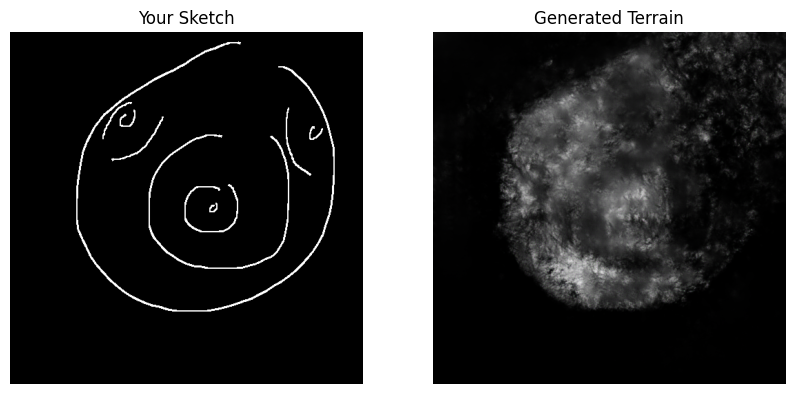

In [38]:
import numpy as np
from IPython.display import HTML, display
from google.colab import output
import cv2
import base64
import matplotlib.pyplot as plt

canvas_html = """
<div style='border: 1px solid #ccc; padding: 20px; width: fit-content; text-align: center;'>
    <h3>Draw your terrain edges here</h3>
    <canvas id='main_canvas' width='512' height='512' style='border:2px solid #000; background: black; cursor: crosshair;'></canvas>
    <br><br>
    <button id='clear_btn'>Clear</button>
    <button id='finish_btn' style='background: #4CAF50; color: white;'>Generate Terrain</button>
</div>
<script>
    var canvas = document.getElementById('main_canvas');
    var ctx = canvas.getContext('2d');
    var drawing = false;
    ctx.strokeStyle = 'white';
    ctx.lineWidth = 2;

    canvas.addEventListener('mousedown', (e) => { drawing = true; ctx.beginPath(); ctx.moveTo(e.offsetX, e.offsetY); });
    canvas.addEventListener('mousemove', (e) => { if(drawing) { ctx.lineTo(e.offsetX, e.offsetY); ctx.stroke(); } });
    canvas.addEventListener('mouseup', () => { drawing = false; });
    document.getElementById('clear_btn').onclick = () => ctx.clearRect(0, 0, 512, 512);

    var getCanvasData = new Promise(resolve => {
        document.getElementById('finish_btn').onclick = () => resolve(canvas.toDataURL('image/png'));
    });
</script>
"""

def get_prediction():
    display(HTML(canvas_html))
    data_url = output.eval_js("getCanvasData")

    # Decode image
    encoded = data_url.split(",")[1]
    nparr = np.frombuffer(base64.b64decode(encoded), np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocess for pix2pixHD
    img_t = torch.from_numpy(img_rgb).permute(2, 0, 1).float().unsqueeze(0)
    img_t = (img_t / 127.5) - 1.0 # Scale to [-1, 1]

    # Inference
    with torch.no_grad():
        generated = model.inference(img_t.to(device), None)

    # Post-process
    res = generated.squeeze().cpu().numpy()
    res = (np.transpose(res, (1, 2, 0)) + 1) / 2.0
    res = np.clip(res, 0, 1)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img_rgb); plt.title("Your Sketch"); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(res); plt.title("Generated Terrain"); plt.axis('off')
    plt.show()

get_prediction()